In [ ]:
# 1. Install Dependencies
%pip install -qU langchain-groq langchain-community langgraph python-dotenv pypdf2 pytesseract pillow pdf2image PyMuPDF
%pip install -qU "langgraph>=0.2.0" langchain-groq langchain-community langgraph-checkpoint-sqlite

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
from dotenv import load_dotenv
import os
import sqlite3

In [ ]:
from datetime import datetime
import sqlite3

class DatabaseAgent:
    def __init__(self, db_path="documents.db"):
        self.conn = sqlite3.connect(db_path)
        self._create_table()

    def _create_table(self):
        query = """
        CREATE TABLE IF NOT EXISTS documents (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            date_received TEXT NOT NULL,
            document_name TEXT NOT NULL,
            extracted_details TEXT NOT NULL,
            confidence_score REAL,
            reasoning TEXT,
            classification TEXT,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
        """
        self.conn.execute(query)
        self.conn.commit()

    def store_document(self, date_received: str, document_name: str, extracted_details: str, confidence_score: float = None, reasoning: str = None, classification: str = None):
        query = """
        INSERT INTO documents (date_received, document_name, extracted_details, confidence_score, reasoning, classification)
        VALUES (?, ?, ?, ?, ?, ?)
        """
        self.conn.execute(query, (date_received, document_name, extracted_details, confidence_score, reasoning, classification))
        self.conn.commit()

    def query_documents(self, query: str, params: tuple = None):
        params = () if params is None else params
        cursor = self.conn.execute(query, params)
        return cursor.fetchall()

    def close(self):
        self.conn.close()

In [7]:
# 2. Setup API Keys

import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get GroQ API key from environment
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY not found in .env file")

# Initialize LLM
llm = ChatGroq(
    model="qwen/qwen3-32b",
        temperature=0,
    reasoning_format="parsed",
    api_key=groq_api_key    
)
sys_msg = SystemMessage(content="""You are a compliance-focused assistant analyzing text from PDF documents 
(including scanned text and OCR outputs). 

Classification rules:
1. Cease - Formal cease and desist letters demanding unlawful activity stop.
2. Irrelevant - Administrative, procedural, or informational notices that are not cease and desist demands.
3. Uncertain - Cases where the content is blocked, incomplete, or unclear.

Workflow:
- Step 1: If the document is scanned or image-based, invoke OCR extraction tools to obtain text before classification.
- Step 2: Apply classification rules to the extracted text.
- Step 3: Assign confidence_score (0-100) based on clarity:
   - >80 if cease-and-desist keywords and clear intent are present.
   - 40-80 if ambiguous or partially clear.
   - <40 if irrelevant or lacking cease-and-desist language.

For each document:
- Provide the filename.
- State the classification (Cease, Irrelevant, or Uncertain).
- Briefly explain the reason for classification.
- Assign a confidence_score (0-100) based on clarity:
   - >80 if cease-and-desist keywords and clear intent are present.
   - 40-80 if ambiguous or partially clear.
   - <40 if irrelevant or lacking cease-and-desist language.

Output requirements:
- Always respond in valid JSON format.
- Ensure the JSON contains exactly these keys:
  {
    "classification": "Cease/Uncertain/Irrelevant",
    "confidence_score": <integer between 0 and 100>,
                        if extracted text has cease & desist keywords and clear intent, confidence should be above 80.
                         If the text is ambiguous or lacks clear intent, confidence should be between 40 and 80. 
                        If the text is irrelevant or does not contain cease & desist keywords, confidence should be below 40.
    "reasoning": "<concise explanation of classification and confidence score>"
  }""")



In [8]:
# --- State definition ---
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    metadata: dict
    text: str
    classification: str
    explanation: str
    action: str
    document_name: str
    document_path: str
    document_content: str | None
    is_scanned: bool | None
    audit_log: list
    confidence_score: int
    reasoning: str    


    

In [9]:
import json
from langchain_core.messages import HumanMessage
def scanned_doc(state: AgentState) -> AgentState:
    """ Scanned document processing function: Extract text using OCR if the document is scanned, then classify using LLM. """
    # Run LLM with system + human message
    response = llm.invoke([sys_msg, HumanMessage(content=state["text"])])
    
    llm_response = response.content   # AIMessage → get string
    
    print("LLM response:", llm_response)

    try:
        result = json.loads(llm_response)  # parse JSON string
        state["classification"] = result.get("classification", "")
        state["confidence_score"] = result.get("confidence_score", 0)
        state["reasoning"] = result.get("reasoning", "")
    except json.JSONDecodeError:
        state["classification"] = "Uncertain"
        state["confidence_score"] = 0
        state["reasoning"] = "LLM response was not valid JSON"
    stage="Scanned:"
    audit_fn(state, stage)
    return state


def classify_fn(state: AgentState) -> AgentState:
    """ Classification function: Use LLM output to determine next action based on classification and confidence score. """
    # Use classification logic
    if state["classification"] == "Cease":
        state["next_action"] = "Proceed with cease & desist process"
    elif state["classification"] == "Uncertain":
        state["next_action"] = "Route to HITL/manual review"
    elif state["classification"] == "Irrelevant":
        state["next_action"] = "Discard or archive as non-cease"
    else:
        state["next_action"] = "Manual check required"

    print(f"Confidence: {state['confidence_score']}")
    print(f"Reasoning: {state['reasoning']}")
    audit_fn(state, stage="Classification")
    return state

def store_db_fn(state: AgentState) -> AgentState:
    """Store document details in the database using DatabaseAgent."""
    db_agent = DatabaseAgent()
    db_agent.store_document(
        date_received=datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        document_name=state["document_name"],
        extracted_details=state["text"],
        confidence_score=state["confidence_score"],
        reasoning=state["reasoning"],
        classification=state["classification"]
    )
    db_agent.close()
    db_agent.close()
    stage="Stored document details in database:"
    audit_fn(state, stage)
    return state
def archive_fn(state: AgentState) -> AgentState:
    """ Archive function: Simulate archiving the document by writing metadata to a flat file and updating state. """
    # Print to console for visibility
    print(f"ARCHIVE: {state['metadata']}")

    # Update state
    state["action"] = "Archived"
    log_entry = f"Archived document: {state['document_name']}"
    state["audit_log"].append(log_entry)

    # Write archival data to a flat file
    with open("archive_log.txt", "a") as f:
        f.write(f"Metadata: {state['metadata']}\n")
        f.write(f"Action: {state['action']}\n")
        f.write(f"{log_entry}\n")
        f.write("-" * 40 + "\n")
    stage="Archived document:"
    audit_fn(state, stage)
    return state

def hitl_fn(state: AgentState) -> AgentState:
    """ Human-in-the-loop function:
    If classification is uncertain, send for human review,
    log the event, and wait for human feedback before proceeding.
    """
    if state["classification"] == "Uncertain":
        # Log the HITL trigger
        state["audit_log"].append(
            f"Document sent for human review: {state['document_name']}"
        )
        
        # Simulate sending to human reviewer (could be UI, queue, etc.)
        print(f"⚠️ Human review required for: {state['document_name']}")
        
        # Block until human provides classification decision
        
        human_input = input("Enter classification (Approved/Rejected/Other): ")
        
        # Update state with human decision
        state["classification"] = human_input
        state["audit_log"].append(
            f"Human classified document '{state['document_name']}' as: {human_input}"
        )
    stage="HITL Review:"
    audit_fn(state, stage)
    return state

def audit_fn(state: AgentState, stage: str = "unspecified") -> AgentState:
    """
    Append an audit entry to the state log with stage info.
    
    Args:
        state (AgentState): Current agent state dictionary.
        stage (str): Workflow stage where audit is called.
    
    Returns:
        AgentState: Updated state with appended audit log.
    """
    # Ensure audit_log exists
    if "audit_log" not in state:
        state["audit_log"] = []

    # Safely extract values
    doc_name = state.get("document_name", "Unknown Document")
    classification = state.get("classification", "Unclassified")

    # Append structured audit entry
    state["audit_log"].append(
        f"[Stage: {state.get('stage', 'unspecified')}] Audit completed for document: {doc_name} "
        f"with classification: {classification}"
    )
    print(f"Audit log updated at stage '{stage}' for document '{doc_name}'")
    return state


In [10]:
# --- Graph construction ---
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("ScannedDocAgent", scanned_doc)
#graph.add_node("IngestionAgent", ingestion_fn)
graph.add_node("ClassificationAgent", classify_fn)
graph.add_node("DatabaseAgent", store_db_fn)
graph.add_node("ArchivingAgent", archive_fn)
graph.add_node("HITLAgent", hitl_fn)
graph.add_node("AuditAgent", audit_fn)

graph.add_edge(START, "ScannedDocAgent")
#graph.add_edge("ScannedDocAgent", "IngestionAgent")
#graph.add_edge("IngestionAgent", "ClassificationAgent")
graph.add_edge("ScannedDocAgent", "ClassificationAgent")
graph.add_conditional_edges(
  "ClassificationAgent",
 lambda state: state["classification"],
{
  "Irrelevant": "ArchivingAgent",
   "Uncertain": "HITLAgent",
   "Cease": "DatabaseAgent"
}
)
graph.add_edge("DatabaseAgent", "AuditAgent")
graph.add_edge("ArchivingAgent", "AuditAgent")
graph.add_edge("HITLAgent", "AuditAgent")
graph.add_edge("AuditAgent", END)
#graph.add_edge("ScannedDocAgent", END)


# Compile the graph
graph = graph.compile()

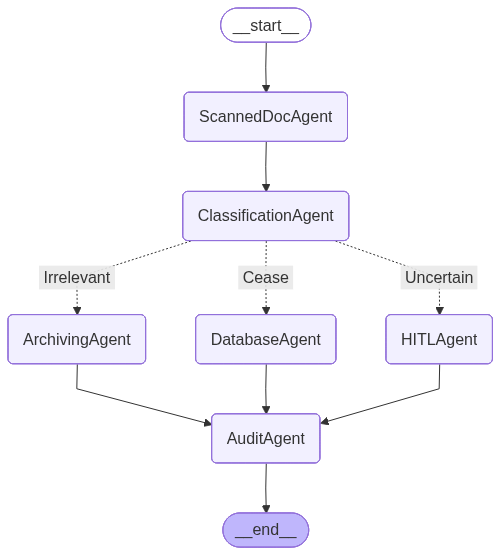

In [11]:
from IPython.display import Image, display
# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
# --- Process all documents in the DataFiles folder ---
folder_path = os.path.join(os.getcwd(), "DataFiles")

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    if not os.path.isfile(file_path):
        continue

    print(f"\nProcessing: {filename}")

    initial_state = {
        "document_name": filename,
        "document_path": file_path,
        "document_content": None,
        "is_scanned": None,
        "audit_log": [],
        "text": "",          # required by classify_fn
        "metadata": {"path": file_path, "name": filename},
        "classification": "",
        "explanation": "",
        "action": "",
        "confidence_score": 0,
        "reasoning": ""
    }

    result = graph.invoke(initial_state) 
    





Processing: 01_copyright_infringement_photography.pdf
LLM response: {  "classification": "Irrelevant",
  "confidence_score": 30,
  "reasoning": "The text contains a notice of meeting and administrative details but lacks any cease-and-desist language or demands to stop unlawful activity. It is a procedural communication unrelated to legal threats."
}
Audit log updated at stage 'Scanned:' for document '01_copyright_infringement_photography.pdf'
Confidence: 30
Reasoning: The text contains a notice of meeting and administrative details but lacks any cease-and-desist language or demands to stop unlawful activity. It is a procedural communication unrelated to legal threats.
Audit log updated at stage 'Classification' for document '01_copyright_infringement_photography.pdf'
ARCHIVE: {'path': 'd:\\GenAI_Training\\LangChain\\DataFiles\\01_copyright_infringement_photography.pdf', 'name': '01_copyright_infringement_photography.pdf'}
Audit log updated at stage 'Archived document:' for document '0

In [15]:
db_agent = DatabaseAgent(db_path="documents.db")

# Query for count of records with a specific condition
results = db_agent.query_documents(
  "SELECT COUNT(*) FROM documents WHERE classification='Cease'"
  # "SELECT COUNT(*) FROM documents WHERE confidence_score > ?", (80,) 
   
)

# Extract the count value
count = results[0][0]

print("Count of matching documents:", count)

db_agent.close()


Count of matching documents: 14
